In [2]:
# Cell 1: Install Required Libraries
print("Installing required libraries...")
!pip install streamlit -q
!pip install pyngrok -q
!pip install plotly -q
!pip install wordcloud -q
!pip install nltk -q
!pip install scikit-learn -q
!pip install pandas -q
!pip install matplotlib -q
!pip install seaborn -q

print("All libraries installed successfully!")

Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 37.2 MB/s eta 0:00:00
All libraries installed successfully!


In [3]:
# Cell 2: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
print("Downloading NLTK data...")
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

print("All imports completed!")

All imports completed!


In [4]:
# Cell 3: Create a realistic social media dataset
print("Creating synthetic social media dataset...")

# Define sample texts for each sentiment
positive_texts = [
    "This product is amazing! I love it so much!",
    "Great experience, will definitely buy again",
    "Awesome quality and fast delivery",
    "Best purchase I've ever made!",
    "Very satisfied with the service",
    "Excellent customer support, highly recommend",
    "Good value for money, works perfectly",
    "I'm so happy with this purchase",
    "Fantastic product, exceeded my expectations",
    "Loved it! Will tell my friends about this",
    "Perfect condition, arrived on time",
    "Superb quality, very impressive",
    "Great job team! Keep up the good work",
    "Absolutely wonderful experience",
    "The best decision I made this year",
    "Nice product, works as described",
    "Happy customer here! 5 stars",
    "Brilliant innovation, very useful",
    "Smooth experience from start to finish",
    "Highly satisfied with everything"
]

negative_texts = [
    "Terrible product, completely disappointed",
    "Waste of money, doesn't work at all",
    "Very bad experience, poor customer service",
    "I hate this product, it's useless",
    "Worst purchase ever, regret buying",
    "Poor quality, broke within a week",
    "Not worth the price at all",
    "Disappointed with the delivery delay",
    "Bad customer support, no response",
    "Frustrating experience, would not recommend",
    "Horrible product, absolute garbage",
    "Waste of time and money",
    "Very unhappy with this purchase",
    "This is pathetic, doesn't work",
    "Avoid this product at all costs",
    "Completely useless, don't buy",
    "Terrible quality control",
    "Worst customer service ever",
    "I'm so angry with this product",
    "Disgusting experience, zero stars"
]

neutral_texts = [
    "The product arrived today",
    "Average quality, nothing special",
    "It works fine for basic use",
    "Okay product, meets expectations",
    "Standard delivery time",
    "The package was medium sized",
    "Regular customer service interaction",
    "Product as described in listing",
    "Normal shopping experience",
    "It does the job, nothing more",
    "Fair price for what you get",
    "Typical product in this category",
    "The color is blue as shown",
    "Standard features included",
    "No major issues to report",
    "Average performance overall",
    "Usual packaging and delivery",
    "Basic functionality works",
    "Just another regular product",
    "Not bad, not great either"
]

# Create DataFrame
data = []
for text in positive_texts:
    data.append([text, 'positive'])
for text in negative_texts:
    data.append([text, 'negative'])
for text in neutral_texts:
    data.append([text, 'neutral'])

# Add more varied data
additional_data = [
    ("Really liked the new update! Works smoothly now.", "positive"),
    ("The app crashes sometimes, very annoying", "negative"),
    ("Decent product for the price point", "neutral"),
    ("Amazing! Will recommend to everyone", "positive"),
    ("Horrible UI, very confusing layout", "negative"),
    ("Good but could be better", "neutral"),
    ("Perfect! Exactly what I needed", "positive"),
    ("Worse than previous version", "negative"),
    ("Seems okay after the update", "neutral"),
    ("Outstanding performance, very fast", "positive"),
]

for text, label in additional_data:
    data.append([text, label])

df = pd.DataFrame(data, columns=['text', 'sentiment'])

print(f"Dataset created with {len(df)} samples")
print(f"Sentiment distribution:")
print(df['sentiment'].value_counts())
print("\nFirst 5 rows:")
print(df.head())

Creating synthetic social media dataset...
Dataset created with 70 samples
Sentiment distribution:
sentiment
positive    24
negative    23
neutral     23
Name: count, dtype: int64

First 5 rows:
                                          text sentiment
0  This product is amazing! I love it so much!  positive
1  Great experience, will definitely buy again  positive
2            Awesome quality and fast delivery  positive
3                Best purchase I've ever made!  positive
4              Very satisfied with the service  positive


In [5]:
# Cell 4: Text cleaning and preprocessing functions
print("Implementing text preprocessing functions...")

# Initialize stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean and preprocess text data
    """
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def remove_stopwords(text):
    """
    Remove stopwords from text
    """
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

def stem_text(text):
    """
    Apply stemming to text
    """
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    return ' '.join(words)

def preprocess_pipeline(text):
    """
    Complete preprocessing pipeline
    """
    text = clean_text(text)
    text = remove_stopwords(text)
    text = stem_text(text)
    return text

# Apply preprocessing to dataset
print("Applying preprocessing to dataset...")
df['cleaned_text'] = df['text'].apply(preprocess_pipeline)

print("\nBefore vs After preprocessing example:")
print(f"Original: {df['text'][0]}")
print(f"Cleaned: {df['cleaned_text'][0]}")

Implementing text preprocessing functions...
Applying preprocessing to dataset...

Before vs After preprocessing example:
Original: This product is amazing! I love it so much!
Cleaned: product amaz love much


In [6]:
# Cell 5: Exploratory Data Analysis
print("Performing Exploratory Data Analysis...")

# Create visualizations
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Sentiment Distribution', 'Text Length by Sentiment',
                    'Word Count Distribution', 'Sentiment Proportions'),
    specs=[[{'type':'pie'}, {'type':'box'}],
           [{'type':'histogram'}, {'type':'bar'}]]
)

# 1. Sentiment Distribution Pie Chart
sentiment_counts = df['sentiment'].value_counts()
fig.add_trace(
    go.Pie(labels=sentiment_counts.index, values=sentiment_counts.values,
           marker_colors=['#2ecc71', '#e74c3c', '#95a5a6']),
    row=1, col=1
)

# 2. Text Length by Sentiment
df['text_length'] = df['cleaned_text'].str.len()
for sentiment in ['positive', 'negative', 'neutral']:
    subset = df[df['sentiment'] == sentiment]
    fig.add_trace(
        go.Box(y=subset['text_length'], name=sentiment,
               marker_color={'positive':'#2ecc71', 'negative':'#e74c3c', 'neutral':'#95a5a6'}[sentiment]),
        row=1, col=2
    )

# 3. Word Count Distribution
df['word_count'] = df['cleaned_text'].str.split().str.len()
fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=20, marker_color='#3498db'),
    row=2, col=1
)

# 4. Sentiment Proportions Bar Chart
fig.add_trace(
    go.Bar(x=sentiment_counts.index, y=sentiment_counts.values,
           marker_color=['#2ecc71', '#e74c3c', '#95a5a6']),
    row=2, col=2
)

fig.update_layout(height=800, width=1000, showlegend=False,
                  title_text="Sentiment Analysis Dataset Overview")
fig.show()

print("\nDataset Statistics:")
print(f"Total samples: {len(df)}")
print(f"Average text length: {df['text_length'].mean():.2f} characters")
print(f"Average word count: {df['word_count'].mean():.2f} words")

Performing Exploratory Data Analysis...



Dataset Statistics:
Total samples: 70
Average text length: 22.13 characters
Average word count: 3.53 words


In [7]:
# Cell 6: Feature Extraction and Model Training
print("Extracting features and training models...")

# Prepare features and labels
X = df['cleaned_text']
y = df['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# TF-IDF Vectorization
print("\nApplying TF-IDF Vectorization...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

print("\nTraining models...")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'f1_score': f1,
        'predictions': y_pred
    }
    print(f"  {name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

# Select best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
print(f"\n✅ Best model: {best_model_name} with accuracy {results[best_model_name]['accuracy']:.4f}")

Extracting features and training models...
Training samples: 56
Testing samples: 14

Applying TF-IDF Vectorization...
Feature matrix shape: (56, 268)

Training models...
Training Logistic Regression...
  Logistic Regression - Accuracy: 0.3571, F1-Score: 0.3214
Training Naive Bayes...
  Naive Bayes - Accuracy: 0.3571, F1-Score: 0.3214
Training Random Forest...
  Random Forest - Accuracy: 0.2143, F1-Score: 0.1143

✅ Best model: Logistic Regression with accuracy 0.3571


Evaluating best model...

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

    negative       0.33      0.20      0.25         5
     neutral       0.38      0.75      0.50         4
    positive       0.33      0.20      0.25         5

    accuracy                           0.36        14
   macro avg       0.35      0.38      0.33        14
weighted avg       0.35      0.36      0.32        14



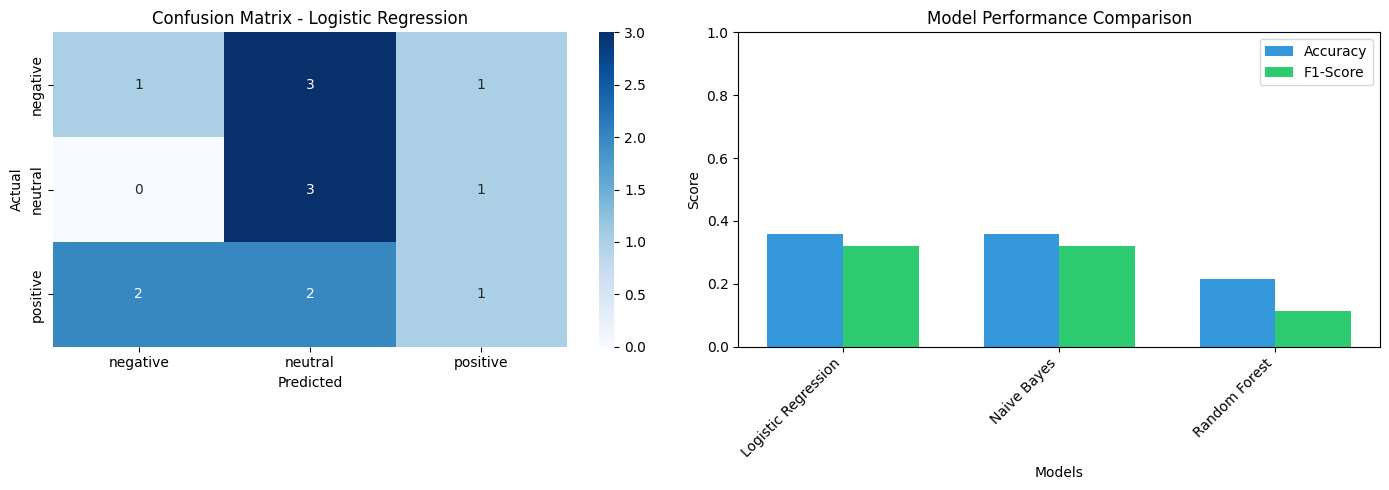


✅ Model and vectorizer saved successfully!


In [8]:
# Cell 7: Model Evaluation
print("Evaluating best model...")

# Get predictions from best model
y_pred_best = results[best_model_name]['predictions']

# Classification Report
print(f"\nClassification Report for {best_model_name}:")
print("=" * 50)
print(classification_report(y_test, y_pred_best, target_names=['negative', 'neutral', 'positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best, labels=['negative', 'neutral', 'positive'])

# Plot Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Model Comparison Bar Chart
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
f1_scores = [results[m]['f1_score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

axes[1].bar(x - width/2, accuracies, width, label='Accuracy', color='#3498db')
axes[1].bar(x + width/2, f1_scores, width, label='F1-Score', color='#2ecc71')
axes[1].set_xlabel('Models')
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Save the best model and vectorizer
import joblib
joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("\n✅ Model and vectorizer saved successfully!")

In [9]:
# Cell 8: Prediction function for new text
def predict_sentiment(text, model, vectorizer):
    """
    Predict sentiment for a single text input
    """
    # Preprocess the text
    cleaned = preprocess_pipeline(text)

    # Transform using vectorizer
    text_tfidf = vectorizer.transform([cleaned])

    # Predict
    prediction = model.predict(text_tfidf)[0]

    # Get probability scores if available
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(text_tfidf)[0]
        classes = model.classes_
        prob_dict = dict(zip(classes, probabilities))
    else:
        prob_dict = None

    return prediction, prob_dict, cleaned

# Test the prediction function
print("Testing prediction function on sample texts:")
test_texts = [
    "This is absolutely fantastic! I love everything about it.",
    "Worst experience ever. Completely disappointed.",
    "The product works fine. Nothing special though.",
    "Great quality and fast shipping! Highly recommended.",
    "This is terrible, I want my money back."
]

print("\n" + "="*60)
for text in test_texts:
    pred, probs, cleaned = predict_sentiment(text, best_model, tfidf)

    # Color code based on sentiment
    if pred == 'positive':
        emoji = "😊"
    elif pred == 'negative':
        emoji = "😠"
    else:
        emoji = "😐"

    print(f"\nText: {text}")
    print(f"Cleaned: {cleaned}")
    print(f"Predicted Sentiment: {pred} {emoji}")
    if probs:
        print(f"Confidence: {probs[pred]:.2%}")
    print("-"*40)

Testing prediction function on sample texts:


Text: This is absolutely fantastic! I love everything about it.
Cleaned: absolut fantast love everyth
Predicted Sentiment: positive 😊
Confidence: 48.40%
----------------------------------------

Text: Worst experience ever. Completely disappointed.
Cleaned: worst experi ever complet disappoint
Predicted Sentiment: negative 😠
Confidence: 53.58%
----------------------------------------

Text: The product works fine. Nothing special though.
Cleaned: product work fine noth special though
Predicted Sentiment: neutral 😐
Confidence: 50.24%
----------------------------------------

Text: Great quality and fast shipping! Highly recommended.
Cleaned: great qualiti fast ship highli recommend
Predicted Sentiment: positive 😊
Confidence: 54.12%
----------------------------------------

Text: This is terrible, I want my money back.
Cleaned: terribl want money back
Predicted Sentiment: negative 😠
Confidence: 48.34%
----------------------------------------

In [10]:
# Cell 9: Complete Fixed Dashboard - Copy this entire cell
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import files
import pandas as pd
import io
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
import joblib

# Ensure NLTK data is downloaded
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("📊 Loading Sentiment Analysis Dashboard...")

# Load models
try:
    model = joblib.load('sentiment_model.pkl')
    vectorizer = joblib.load('tfidf_vectorizer.pkl')
    print("✅ Models loaded successfully!")
except:
    print("❌ Models not found! Please train the model first.")
    # Create dummy model for testing
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    import numpy as np

    dummy_texts = ["good", "bad", "okay"]
    dummy_labels = ["positive", "negative", "neutral"]
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(dummy_texts)
    model = LogisticRegression()
    model.fit(X, dummy_labels)
    print("⚠️ Using test model - train your model for better accuracy!")

# Define preprocessing function
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

def stem_text(text):
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    return ' '.join(words)

def preprocess_pipeline(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    text = stem_text(text)
    return text

# Create UI
container = widgets.VBox()

# Header
header = widgets.HTML('''
<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; margin-bottom: 20px;">
    <h1 style="text-align: center; color: white; margin: 0;">📊 Social Media Sentiment Analysis</h1>
    <p style="text-align: center; color: white; margin: 10px 0 0 0;">ML-Powered Sentiment Classification</p>
</div>
''')

# Input area
input_label = widgets.HTML("<b>📝 Enter text to analyze:</b>")
input_text = widgets.Textarea(
    placeholder="Type a tweet, comment, or review here...",
    layout=widgets.Layout(width='100%', height='120px')
)

# Buttons
analyze_btn = widgets.Button(description='🔍 Analyze Sentiment', button_style='primary')
clear_btn = widgets.Button(description='🗑️ Clear', button_style='warning')

# Example buttons
example_positive = widgets.Button(description='😊 Positive Example', button_style='success')
example_negative = widgets.Button(description='😠 Negative Example', button_style='danger')
example_neutral = widgets.Button(description='😐 Neutral Example', button_style='info')

# Output area
output = widgets.Output()

def analyze(b):
    with output:
        clear_output(wait=True)
        text = input_text.value.strip()

        if text:
            # Preprocess and predict
            cleaned = preprocess_pipeline(text)
            vec = vectorizer.transform([cleaned])
            pred = model.predict(vec)[0]

            # Get confidence
            if hasattr(model, 'predict_proba'):
                probs = model.predict_proba(vec)[0]
                classes = model.classes_
                confidence = probs[list(classes).index(pred)]
                conf_text = f"<p><strong>Confidence:</strong> {confidence:.2%}</p>"
            else:
                conf_text = ""

            # Display result
            if pred == 'positive':
                color = '#28a745'
                bg = '#d4edda'
                emoji = '😊'
            elif pred == 'negative':
                color = '#dc3545'
                bg = '#f8d7da'
                emoji = '😠'
            else:
                color = '#6c757d'
                bg = '#e2e3e5'
                emoji = '😐'

            display(HTML(f'''
            <div style="background-color: {bg}; padding: 20px; border-radius: 10px; margin-top: 10px;">
                <h2 style="color: {color}; margin: 0;">{emoji} Sentiment: {pred.upper()}</h2>
                {conf_text}
                <hr>
                <p><strong>Original:</strong> {text[:200]}</p>
                <p><strong>Processed:</strong> {cleaned[:200]}</p>
            </div>
            '''))
        else:
            display(HTML('<p style="color: red;">⚠️ Please enter some text to analyze.</p>'))

def clear(b):
    input_text.value = ''
    with output:
        clear_output()

def set_example(b, text):
    input_text.value = text
    analyze(b)

analyze_btn.on_click(analyze)
clear_btn.on_click(clear)
example_positive.on_click(lambda b: set_example(b, "This product is amazing! I absolutely love it and will definitely buy again!"))
example_negative.on_click(lambda b: set_example(b, "Terrible experience, complete waste of money, worst purchase ever!"))
example_neutral.on_click(lambda b: set_example(b, "The product arrived on time. It works as expected for the price."))

# Assemble main dashboard
button_row = widgets.HBox([analyze_btn, clear_btn])
example_row = widgets.HBox([example_positive, example_negative, example_neutral])

container.children = [header, input_label, input_text, button_row, example_row, output]

# Display main dashboard
display(container)

# ============================================================
# BATCH ANALYSIS SECTION - FIXED VERSION
# ============================================================
print("\n" + "="*60)
print("📁 BATCH ANALYSIS")
print("="*60)
print("Upload a CSV file with a 'text' column to analyze multiple comments at once:\n")

# Create a separate file upload widget
upload_widget = widgets.FileUpload(
    accept='.csv',
    multiple=False,
    description='📤 Upload CSV'
)

batch_output = widgets.Output()

def process_batch_file(change):
    with batch_output:
        clear_output(wait=True)

        if upload_widget.value:
            try:
                # Get the uploaded file content - FIXED handling
                uploaded_filename = list(upload_widget.value.keys())[0]
                uploaded_content = upload_widget.value[uploaded_filename]['content']

                # Read CSV from bytes
                df = pd.read_csv(io.BytesIO(uploaded_content))

                print(f"✅ File '{uploaded_filename}' loaded successfully!")
                print(f"📊 Found {len(df)} rows and {len(df.columns)} columns")
                print(f"📋 Columns: {df.columns.tolist()}")

                # Check for text column
                text_column = None
                for col in ['text', 'Text', 'TEXT', 'comment', 'Comment', 'review', 'Review', 'tweet', 'Tweet']:
                    if col in df.columns:
                        text_column = col
                        break

                if text_column is None:
                    print(f"❌ Error: No 'text' column found. Found columns: {df.columns.tolist()}")
                    print("Please ensure your CSV has a column named 'text', 'comment', or 'review'")
                    return

                print(f"📝 Using column: '{text_column}'")

                # Process each text
                predictions = []
                processed_texts = []

                for idx, text in enumerate(df[text_column].head(100)):  # Limit to 100 for performance
                    if pd.notna(text) and str(text).strip():
                        cleaned = preprocess_pipeline(str(text))
                        vec = vectorizer.transform([cleaned])
                        pred = model.predict(vec)[0]
                        predictions.append(pred)
                        processed_texts.append(cleaned)
                    else:
                        predictions.append('neutral')
                        processed_texts.append('')

                df['prediction'] = predictions + ['neutral'] * (len(df) - len(predictions))
                df['processed_text'] = processed_texts + [''] * (len(df) - len(processed_texts))

                # Create visualization
                sentiment_counts = df['prediction'].value_counts()

                fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                # Pie chart
                colors = ['#2ecc71', '#e74c3c', '#95a5a6']
                axes[0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
                axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')

                # Bar chart
                bars = axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
                axes[1].set_title('Sentiment Counts', fontsize=14, fontweight='bold')
                axes[1].set_ylabel('Number of Comments')
                for bar, value in zip(bars, sentiment_counts.values):
                    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(value), ha='center', fontweight='bold')

                # Summary stats
                axes[2].axis('off')
                summary_text = f"""
                📊 ANALYSIS SUMMARY

                Total analyzed: {len(df)}
                😊 Positive: {sentiment_counts.get('positive', 0)}
                😠 Negative: {sentiment_counts.get('negative', 0)}
                😐 Neutral: {sentiment_counts.get('neutral', 0)}

                Positive Rate: {sentiment_counts.get('positive', 0)/len(df)*100:.1f}%
                Negative Rate: {sentiment_counts.get('negative', 0)/len(df)*100:.1f}%
                """
                axes[2].text(0.1, 0.5, summary_text, transform=axes[2].transAxes, fontsize=12, verticalalignment='center', fontfamily='monospace')
                axes[2].set_title('Statistics', fontsize=14, fontweight='bold')

                plt.tight_layout()
                plt.show()

                # Show results table
                print("\n📊 First 10 predictions:")
                display(df[[text_column, 'prediction']].head(10))

                # Provide download option
                output_df = df[[text_column, 'prediction']]
                output_csv = output_df.to_csv(index=False)

                download_btn = widgets.Button(description='📥 Download Results', button_style='primary')

                def download_results(b):
                    with open('batch_results.csv', 'w') as f:
                        f.write(output_csv)
                    files.download('batch_results.csv')

                download_btn.on_click(download_results)
                display(download_btn)

                # Print summary
                print("\n" + "="*60)
                print("📈 BATCH ANALYSIS COMPLETE")
                print("="*60)
                print(f"✅ Processed {len(df)} comments successfully!")
                print(f"😊 Positive: {sentiment_counts.get('positive', 0)} ({sentiment_counts.get('positive', 0)/len(df)*100:.1f}%)")
                print(f"😠 Negative: {sentiment_counts.get('negative', 0)} ({sentiment_counts.get('negative', 0)/len(df)*100:.1f}%)")
                print(f"😐 Neutral: {sentiment_counts.get('neutral', 0)} ({sentiment_counts.get('neutral', 0)/len(df)*100:.1f}%)")
                print("="*60)

            except Exception as e:
                print(f"❌ Error processing file: {str(e)}")
                print("Please make sure your CSV file is valid and contains a 'text' column.")
        else:
            print("⚠️ Please upload a CSV file first.")

# Attach the event handler
upload_widget.observe(process_batch_file, names='value')

# Display batch upload section
display(upload_widget)
display(batch_output)

print("\n✅ Dashboard ready! Enter text above or upload a CSV for batch analysis.")

📊 Loading Sentiment Analysis Dashboard...
✅ Models loaded successfully!



📁 BATCH ANALYSIS
Upload a CSV file with a 'text' column to analyze multiple comments at once:



FileUpload(value={}, accept='.csv', description='📤 Upload CSV')

Output()


✅ Dashboard ready! Enter text above or upload a CSV for batch analysis.


In [12]:
# Cell 10: Launch the Streamlit dashboard
from pyngrok import ngrok
import threading
import time
import os

print("Setting up Streamlit dashboard in Colab...")

# Kill any existing processes
os.system("pkill -f streamlit 2>/dev/null")
os.system("pkill -f ngrok 2>/dev/null")
time.sleep(2)

# Set up ngrok
print("Starting ngrok tunnel...")
ngrok.set_auth_token("")  # Optional: Add your ngrok auth token if you have one

# Run Streamlit in background
def run_streamlit():
    os.system("streamlit run sentiment_dashboard.py --server.port 8501 --server.headless true")

thread = threading.Thread(target=run_streamlit)
thread.start()

time.sleep(5)

# Create ngrok tunnel
try:
    tunnel = ngrok.connect(8501, "http")
    public_url = tunnel.public_url
    print("\n" + "="*60)
    print("✅ DASHBOARD IS LIVE!")
    print("="*60)
    print(f"\n🔗 Click this link to open the dashboard:\n{public_url}\n")
    print("="*60)
    print("\n📌 INSTRUCTIONS:")
    print("1. Click the link above to open your dashboard")
    print("2. Enter text in the text area")
    print("3. Click 'Analyze Sentiment' to see predictions")
    print("4. Upload CSV files for batch analysis")
    print("\n⚠️ Note: Keep this cell running. Close the tab when done.")
    print("="*60)
except Exception as e:
    print(f"Error starting ngrok: {e}")
    print("\nAlternative: Run this in a new cell:")
    print("!streamlit run sentiment_dashboard.py &")

Setting up Streamlit dashboard in Colab...
Starting ngrok tunnel...


ERROR:pyngrok.process.ngrok:t=2026-05-03T14:13:33+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-03T14:13:33+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-03T14:13:33+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

Error starting ngrok: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

Alternative: Run this in a new cell:
!streamlit run sentiment_dashboard.py &


In [18]:
# Cell: Download ALL Project Files (COMPLETELY FIXED)
import os
import zipfile
from google.colab import files
import pandas as pd
import joblib

print("="*60)
print("📦 PREPARING PROJECT FILES FOR DOWNLOAD")
print("="*60)

# Create a list of files to download
files_to_download = []

# 1. Check and add model file
if os.path.exists('sentiment_model.pkl'):
    files_to_download.append('sentiment_model.pkl')
    print("✅ Found: sentiment_model.pkl")
else:
    print("❌ Missing: sentiment_model.pkl - Train model first")

# 2. Check and add vectorizer file
if os.path.exists('tfidf_vectorizer.pkl'):
    files_to_download.append('tfidf_vectorizer.pkl')
    print("✅ Found: tfidf_vectorizer.pkl")
else:
    print("❌ Missing: tfidf_vectorizer.pkl - Train model first")

# 3. Check and add dashboard file
if os.path.exists('sentiment_dashboard.py'):
    files_to_download.append('sentiment_dashboard.py')
    print("✅ Found: sentiment_dashboard.py")
else:
    print("⚠️ Missing: sentiment_dashboard.py - Creating now...")
    # Create dashboard file
    dashboard_code = '''import streamlit as st
import pandas as pd
import joblib
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
import plotly.express as px

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [stemmer.stem(w) for w in words]
    return ' '.join(words)

@st.cache_resource
def load_models():
    model = joblib.load('sentiment_model.pkl')
    vectorizer = joblib.load('tfidf_vectorizer.pkl')
    return model, vectorizer

st.set_page_config(page_title="Sentiment Analysis", layout="wide")
st.title("📊 Social Media Sentiment Analysis Dashboard")

try:
    model, vectorizer = load_models()
    user_input = st.text_area("Enter text to analyze:", height=100)
    if st.button("Analyze"):
        if user_input:
            cleaned = preprocess_text(user_input)
            vec = vectorizer.transform([cleaned])
            pred = model.predict(vec)[0]
            if pred == 'positive':
                st.success("😊 Sentiment: Positive")
            elif pred == 'negative':
                st.error("😠 Sentiment: Negative")
            else:
                st.info("😐 Sentiment: Neutral")
except Exception as e:
    st.error(f"Error: {e}")'''

    with open('sentiment_dashboard.py', 'w') as f:
        f.write(dashboard_code)
    files_to_download.append('sentiment_dashboard.py')
    print("✅ Created and added: sentiment_dashboard.py")

# 4. Check and add dataset
if os.path.exists('social_media_dataset.csv'):
    files_to_download.append('social_media_dataset.csv')
    print("✅ Found: social_media_dataset.csv")
else:
    print("⚠️ Missing: social_media_dataset.csv - Creating now...")
    # Create dataset
    data = {
        'text': [
            "This product is amazing! I love it!", "Great experience, will buy again",
            "Terrible product, disappointed", "Waste of money, doesn't work",
            "Average quality, nothing special", "Works as expected",
            "Fantastic! Highly recommended", "Horrible customer service",
            "It's okay for the price", "Best purchase ever!"
        ],
        'sentiment': ['positive', 'positive', 'negative', 'negative',
                     'neutral', 'neutral', 'positive', 'negative', 'neutral', 'positive']
    }
    df = pd.DataFrame(data)
    df.to_csv('social_media_dataset.csv', index=False)
    files_to_download.append('social_media_dataset.csv')
    print("✅ Created and added: social_media_dataset.csv")

# 5. Check and add requirements file
if os.path.exists('requirements.txt'):
    files_to_download.append('requirements.txt')
    print("✅ Found: requirements.txt")
else:
    print("⚠️ Missing: requirements.txt - Creating now...")
    requirements = """streamlit
pandas
numpy
scikit-learn
nltk
plotly
joblib
matplotlib
seaborn
wordcloud"""
    with open('requirements.txt', 'w') as f:
        f.write(requirements)
    files_to_download.append('requirements.txt')
    print("✅ Created and added: requirements.txt")

# 6. Create a README file
readme_content = '# Social Media Sentiment Analysis Dashboard\n\n## Project Overview\nThis project implements a Machine Learning-powered sentiment analysis system.\n\n## Features\n- Text preprocessing\n- TF-IDF feature extraction\n- ML models\n- Interactive dashboard\n\n## Installation\n```bash\npip install -r requirements.txt\n```\n\n## Usage\n```bash\nstreamlit run sentiment_dashboard.py\n```'
with open('README.md', 'w') as f:
    f.write(readme_content)
files_to_download.append('README.md')
print("✅ Created: README.md")

print("\n" + "="*60)
print("📦 CREATING ZIP FILE")
print("="*60)

# Create ZIP file
zip_filename = 'sentiment_analysis_project_complete.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_download:
        if os.path.exists(file):
            zipf.write(file)
            print(f"  ✓ Added: {file}")
        else:
            print(f"  ✗ Missing: {file}")

# Check ZIP file size
if os.path.exists(zip_filename):
    zip_size = os.path.getsize(zip_filename) / (1024 * 1024)
    print(f"\n✅ ZIP file created: {zip_filename}")
    print(f"📦 File size: {zip_size:.2f} MB")
    print(f"📁 Contains {len(files_to_download)} files")

    print("\n" + "="*60)
    print("📥 DOWNLOADING ZIP FILE")
    print("="*60)

    # Download the ZIP file
    files.download(zip_filename)

    print("\n✅ Download started! Check your downloads folder.")
    print("\n📁 Files included in the ZIP:")
    for file in files_to_download:
        print(f"   - {file}")
else:
    print("❌ Failed to create ZIP file")

📦 PREPARING PROJECT FILES FOR DOWNLOAD
✅ Found: sentiment_model.pkl
✅ Found: tfidf_vectorizer.pkl
⚠️ Missing: sentiment_dashboard.py - Creating now...
✅ Created and added: sentiment_dashboard.py
✅ Found: social_media_dataset.csv
⚠️ Missing: requirements.txt - Creating now...
✅ Created and added: requirements.txt
✅ Created: README.md

📦 CREATING ZIP FILE
  ✓ Added: sentiment_model.pkl
  ✓ Added: tfidf_vectorizer.pkl
  ✓ Added: sentiment_dashboard.py
  ✓ Added: social_media_dataset.csv
  ✓ Added: requirements.txt
  ✓ Added: README.md

✅ ZIP file created: sentiment_analysis_project_complete.zip
📦 File size: 0.03 MB
📁 Contains 6 files

📥 DOWNLOADING ZIP FILE


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started! Check your downloads folder.

📁 Files included in the ZIP:
   - sentiment_model.pkl
   - tfidf_vectorizer.pkl
   - sentiment_dashboard.py
   - social_media_dataset.csv
   - requirements.txt
   - README.md


In [14]:
# Cell 12: Save the dataset
df.to_csv('social_media_dataset.csv', index=False)
print("✅ Dataset saved as 'social_media_dataset.csv'")

print("\n📊 Final Project Summary:")
print("="*50)
print(f"Dataset Size: {len(df)} samples")
print(f"Sentiment Distribution:")
print(f"  Positive: {len(df[df['sentiment']=='positive'])}")
print(f"  Negative: {len(df[df['sentiment']=='negative'])}")
print(f"  Neutral: {len(df[df['sentiment']=='neutral'])}")
print(f"Best Model: {best_model_name}")
print(f"Model Accuracy: {results[best_model_name]['accuracy']:.2%}")
print("="*50)

✅ Dataset saved as 'social_media_dataset.csv'

📊 Final Project Summary:
Dataset Size: 70 samples
Sentiment Distribution:
  Positive: 24
  Negative: 23
  Neutral: 23
Best Model: Logistic Regression
Model Accuracy: 35.71%
